In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/apate/OneDrive/Documents/ASU Spring2026/FSE570 Capstone/output.csv")
print(df.columns.tolist())

['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES2', 'SMALST

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

keep = [
    '_STATE',
    # outcome
    '_BMI5CAT', '_BMI5',
    # core predictors
    '_SEX', '_AGEG5YR', '_RACE', '_EDUCAG', '_INCOMG1',
    # survey weight
    '_LLCPWT', '_STSTR', '_PSU'
]

df = df[keep].copy()
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")

Shape: (457670, 11)
Columns: ['_STATE', '_BMI5CAT', '_BMI5', '_SEX', '_AGEG5YR', '_RACE', '_EDUCAG', '_INCOMG1', '_LLCPWT', '_STSTR', '_PSU']



In [ ]:
# Per codebook:
missing_map = {
    '_BMI5CAT': [None],          # BLANK = missing
    '_BMI5':    [9999],          # 9999 = missing
    '_SEX':     [],              # no missing codes
    '_AGEG5YR': [14],            # 14 = DK/Refused
    '_RACE':    [9],             # 9 = DK/Refused
    '_EDUCAG':  [9],             # 9 = DK/Refused
    '_INCOMG1': [9],             # 9 = DK/Refused
}

for col, codes in missing_map.items():
    if col in df.columns:
        df[col] = df[col].replace(codes, np.nan)
df.head()

,_STATE,_BMI5CAT,_BMI5,_SEX,_AGEG5YR,_RACE,_EDUCAG,_INCOMG1,_LLCPWT,_STSTR,_PSU
0,1,2.0,2249.0,2,12.0,1.0,2.0,NaN,261.525511,11011,2024000001
1,1,3.0,2583.0,1,13.0,1.0,4.0,7.0,307.169688,11011,2024000002
2,1,2.0,2253.0,1,8.0,1.0,3.0,NaN,2939.862806,11011,2024000003
3,1,3.0,2509.0,1,13.0,1.0,4.0,4.0,153.584844,11011,2024000004
4,1,2.0,1977.0,1,6.0,1.0,3.0,2.0,1229.623036,11011,2024000005


In [ ]:
df['obese'] = (df['_BMI5CAT'] == 4).astype(float)
df.loc[df['_BMI5CAT'].isna(), 'obese'] = np.nan

In [ ]:
print("=== dtypes ===")
print(df.dtypes)

print("\n=== Missing value counts ===")
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
print(pd.concat([missing, missing_pct], axis=1, keys=['n_missing', 'pct_missing']))

print("\n=== describe (all cols) ===")
print(df.describe(include='all').T)

=== dtypes ===
_STATE        int64
_BMI5CAT    float64
_BMI5       float64
_SEX          int64
_AGEG5YR    float64
_RACE       float64
_EDUCAG     float64
_INCOMG1    float64
_LLCPWT     float64
_STSTR        int64
_PSU          int64
obese       float64
dtype: object

=== Missing value counts ===
          n_missing  pct_missing
_STATE            0         0.00
_BMI5CAT      43037         9.40
_BMI5         43037         9.40
_SEX              0         0.00
_AGEG5YR       8310         1.82
_RACE          9103         1.99
_EDUCAG        2363         0.52
_INCOMG1      87423        19.10
_LLCPWT           0         0.00
_STSTR            0         0.00
_PSU              0         0.00
obese         43037         9.40

=== describe (all cols) ===
             count          mean            std           min           25%  \
_STATE    457670.0  3.082354e+01      15.939364  1.000000e+00  1.800000e+01   
_BMI5CAT  414633.0  3.009244e+00       0.836549  1.000000e+00  2.000000e+00   
_BMI5 

In [ ]:
expected_ranges = {
    '_BMI5CAT': (1, 4),
    '_BMI5':    (100, 9998),   # 2 implied decimals; 9999 already NaN'd
    '_SEX':     (1, 2),
    '_AGEG5YR': (1, 13),
    '_RACE':    (1, 8),
    '_EDUCAG':  (1, 4),
    '_INCOMG1': (1, 7),
    '_LLCPWT':  (0, None),     # must be positive
}

print("\n=== Range checks ===")
for col, (lo, hi) in expected_ranges.items():
    if col not in df.columns:
        continue
    s = df[col].dropna()
    actual_min, actual_max = s.min(), s.max()
    out_of_range = ((s < lo) | (s > hi)).sum() if hi is not None else (s < lo).sum()
    status = "OK" if out_of_range == 0 else f"⚠ {out_of_range} out-of-range"
    print(f"  {col:12s}  expected [{lo}, {hi if hi else '∞'}]  "
          f"actual [{actual_min:.1f}, {actual_max:.1f}]  {status}")


=== Range checks ===
  _BMI5CAT      expected [1, 4]  actual [1.0, 4.0]  OK
  _BMI5         expected [100, 9998]  actual [1200.0, 9984.0]  OK
  _SEX          expected [1, 2]  actual [1.0, 2.0]  OK
  _AGEG5YR      expected [1, 13]  actual [1.0, 13.0]  OK
  _RACE         expected [1, 8]  actual [1.0, 8.0]  OK
  _EDUCAG       expected [1, 4]  actual [1.0, 4.0]  OK
  _INCOMG1      expected [1, 7]  actual [1.0, 7.0]  OK
  _LLCPWT       expected [0, ∞]  actual [0.0, 49582.2]  OK


In [ ]:
bmi_raw = df['_BMI5'].dropna() / 100   # convert to actual BMI

q1, q3 = bmi_raw.quantile(0.25), bmi_raw.quantile(0.75)
iqr = q3 - q1
lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr

n_outliers = ((bmi_raw < lo_fence) | (bmi_raw > hi_fence)).sum()
print(f"\n=== BMI outliers (IQR method) ===")
print(f"  Q1={q1:.1f}  Q3={q3:.1f}  IQR={iqr:.1f}")
print(f"  Fences: [{lo_fence:.1f}, {hi_fence:.1f}]")
print(f"  Outliers: {n_outliers} ({n_outliers/len(bmi_raw)*100:.2f}%)")
print(f"  BMI > 60: {(bmi_raw > 60).sum()}")
print(f"  BMI < 10: {(bmi_raw < 10).sum()}")



=== BMI outliers (IQR method) ===
  Q1=24.1  Q3=31.8  IQR=7.6
  Fences: [12.7, 43.2]
  Outliers: 13075 (3.15%)
  BMI > 60: 876
  BMI < 10: 0


In [ ]:
wt = df['_LLCPWT'].dropna()
print(f"\n=== Survey weight (_LLCPWT) ===")
print(f"  min={wt.min():.1f}  max={wt.max():.1f}  "
      f"mean={wt.mean():.1f}  median={wt.median():.1f}")
print(f"  Extreme weights (>10x median): {(wt > 10 * wt.median()).sum()}")


=== Survey weight (_LLCPWT) ===
  min=0.0  max=49582.2  mean=576.4  median=263.7
  Extreme weights (>10x median): 15991


In [ ]:
cat_vars = {
    '_SEX':     {1: 'Male', 2: 'Female'},
    '_AGEG5YR': {i: f'Group {i}' for i in range(1, 14)},
    '_RACE':    {1:'NH-White',2:'NH-Black',3:'AIAN',4:'Asian',
                 5:'NHOPI',6:'Other',7:'Multiracial',8:'Hispanic'},
    '_EDUCAG':  {1:'<HS',2:'HS grad',3:'Some college',4:'College grad'},
    '_INCOMG1': {1:'<15k',2:'15-25k',3:'25-35k',4:'35-50k',
                 5:'50-100k',6:'100-200k',7:'200k+'},
    '_BMI5CAT': {1:'Underweight',2:'Normal',3:'Overweight',4:'Obese'},
}

print("\n=== Categorical distributions ===")
for col, labels in cat_vars.items():
    if col not in df.columns:
        continue
    counts = df[col].value_counts(dropna=False).sort_index()
    pct    = (counts / len(df) * 100).round(2)
    tbl    = pd.DataFrame({'n': counts, 'pct': pct})
    tbl.index = [labels.get(i, f'code {i}') if not pd.isna(i) else 'MISSING'
                 for i in tbl.index]
    print(f"\n  {col}")
    print(tbl.to_string())


=== Categorical distributions ===

  _SEX
             n    pct
Male    217507  47.52
Female  240163  52.48

  _AGEG5YR
              n    pct
Group 1   29692   6.49
Group 2   23705   5.18
Group 3   26237   5.73
Group 4   28804   6.29
Group 5   30899   6.75
Group 6   28968   6.33
Group 7   31698   6.93
Group 8   34936   7.63
Group 9   43387   9.48
Group 10  47701  10.42
Group 11  44774   9.78
Group 12  36803   8.04
Group 13  41756   9.12
MISSING    8310   1.82

  _RACE
                  n    pct
NH-White     329346  71.96
NH-Black      35172   7.69
AIAN           6460   1.41
Asian         12646   2.76
NHOPI          2074   0.45
Other          3737   0.82
Multiracial   10486   2.29
Hispanic      48646  10.63
MISSING        9103   1.99

  _EDUCAG
                   n    pct
<HS            27149   5.93
HS grad       115877  25.32
Some college  120732  26.38
College grad  191549  41.85
MISSING         2363   0.52

  _INCOMG1
               n    pct
<15k       20800   4.54
15-25k     33503

In [ ]:
print("\n=== Weighted obesity prevalence by predictor ===")
sub = df.dropna(subset=['obese', '_LLCPWT'])

for col in ['_SEX', '_AGEG5YR', '_RACE', '_EDUCAG', '_INCOMG1']:
    if col not in sub.columns:
        continue
    grp = (sub.groupby(col, dropna=True)
              .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))
              .mul(100).round(2))
    print(f"\n  {col}")
    print(grp.to_string())


=== Weighted obesity prevalence by predictor ===

  _SEX
_SEX
1    32.25
2    34.00

  _AGEG5YR
_AGEG5YR
1.0     20.92
2.0     30.66
3.0     35.52
4.0     36.06
5.0     37.97
6.0     38.96
7.0     40.20
8.0     40.16
9.0     36.51
10.0    34.68
11.0    32.67
12.0    28.70
13.0    19.79

  _RACE
_RACE
1.0    32.43
2.0    41.83
3.0    40.59
4.0    13.46
5.0    37.71
6.0    30.36
7.0    33.24
8.0    35.97


C:\Users\apate\AppData\Local\Temp\ipykernel_3420\1932547585.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))
C:\Users\apate\AppData\Local\Temp\ipykernel_3420\1932547585.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))
C:\Users\apate\AppData\Local\Temp\ipykernel_3420\1932547585.


  _EDUCAG
_EDUCAG
1.0    37.56
2.0    35.39
3.0    35.75
4.0    27.38

  _INCOMG1
_INCOMG1
1.0    37.23
2.0    37.25
3.0    36.93
4.0    36.21
5.0    35.12
6.0    32.85
7.0    23.22


C:\Users\apate\AppData\Local\Temp\ipykernel_3420\1932547585.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))


C:\Users\apate\AppData\Local\Temp\ipykernel_3420\1538758051.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))
C:\Users\apate\AppData\Local\Temp\ipykernel_3420\1538758051.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))
C:\Users\apate\AppData\Local\Temp\ipykernel_3420\153875805

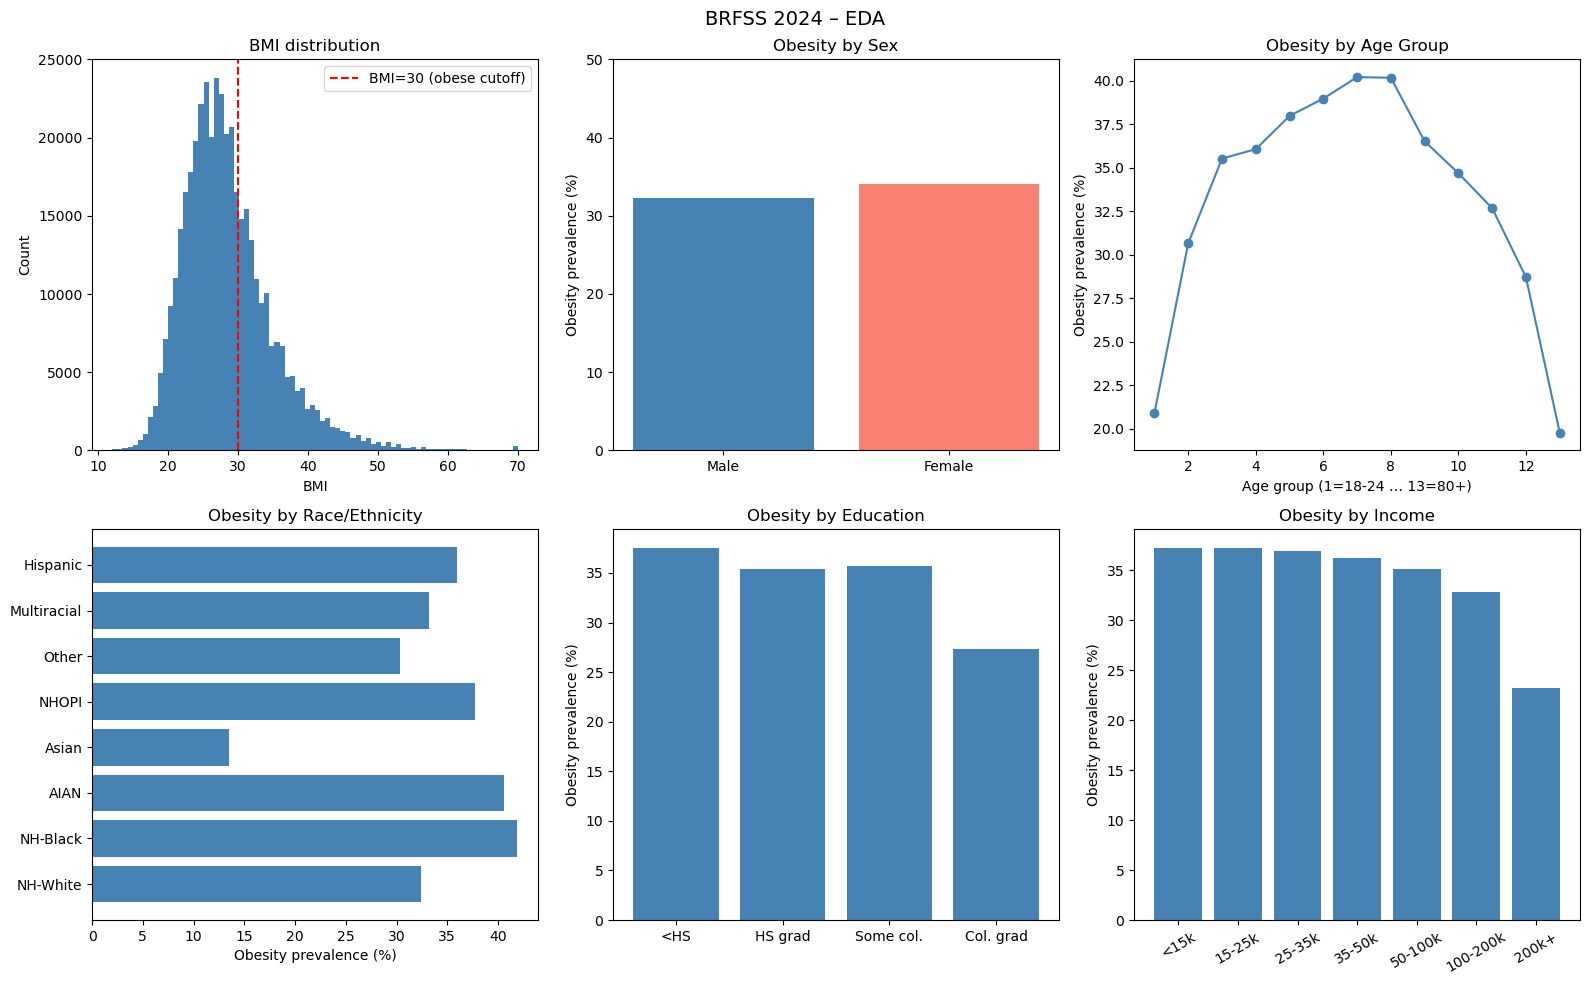

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('BRFSS 2024 – EDA', fontsize=14)

# BMI distribution
ax = axes[0, 0]
ax.hist(bmi_raw.clip(upper=70), bins=80, color='steelblue', edgecolor='none')
ax.axvline(30, color='red', linestyle='--', label='BMI=30 (obese cutoff)')
ax.set_xlabel('BMI'); ax.set_ylabel('Count'); ax.set_title('BMI distribution')
ax.legend()

# Obesity by sex
ax = axes[0, 1]
prev_sex = (sub.groupby('_SEX')
               .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))
               .mul(100))
ax.bar(['Male','Female'], prev_sex.values, color=['steelblue','salmon'])
ax.set_ylabel('Obesity prevalence (%)'); ax.set_title('Obesity by Sex')
ax.set_ylim(0, 50)

# Obesity by age group
ax = axes[0, 2]
prev_age = (sub.groupby('_AGEG5YR')
               .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))
               .mul(100))
ax.plot(prev_age.index, prev_age.values, marker='o', color='steelblue')
ax.set_xlabel('Age group (1=18-24 … 13=80+)')
ax.set_ylabel('Obesity prevalence (%)'); ax.set_title('Obesity by Age Group')

# Obesity by race
ax = axes[1, 0]
race_labels = {1:'NH-White',2:'NH-Black',3:'AIAN',4:'Asian',
               5:'NHOPI',6:'Other',7:'Multiracial',8:'Hispanic'}
prev_race = (sub.groupby('_RACE')
                .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))
                .mul(100))
ax.barh([race_labels.get(i, i) for i in prev_race.index],
        prev_race.values, color='steelblue')
ax.set_xlabel('Obesity prevalence (%)'); ax.set_title('Obesity by Race/Ethnicity')

# Obesity by education
ax = axes[1, 1]
edu_labels = {1:'<HS',2:'HS grad',3:'Some col.',4:'Col. grad'}
prev_edu = (sub.groupby('_EDUCAG')
               .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))
               .mul(100))
ax.bar([edu_labels.get(i, i) for i in prev_edu.index],
       prev_edu.values, color='steelblue')
ax.set_ylabel('Obesity prevalence (%)'); ax.set_title('Obesity by Education')

# Obesity by income
ax = axes[1, 2]
inc_labels = {1:'<15k',2:'15-25k',3:'25-35k',4:'35-50k',
              5:'50-100k',6:'100-200k',7:'200k+'}
prev_inc = (sub.groupby('_INCOMG1')
               .apply(lambda g: np.average(g['obese'], weights=g['_LLCPWT']))
               .mul(100))
ax.bar([inc_labels.get(i, i) for i in prev_inc.index],
       prev_inc.values, color='steelblue')
ax.set_ylabel('Obesity prevalence (%)'); ax.set_title('Obesity by Income')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('brfss_eda.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
df.to_csv('brfss2024_clean_20260402.csv')